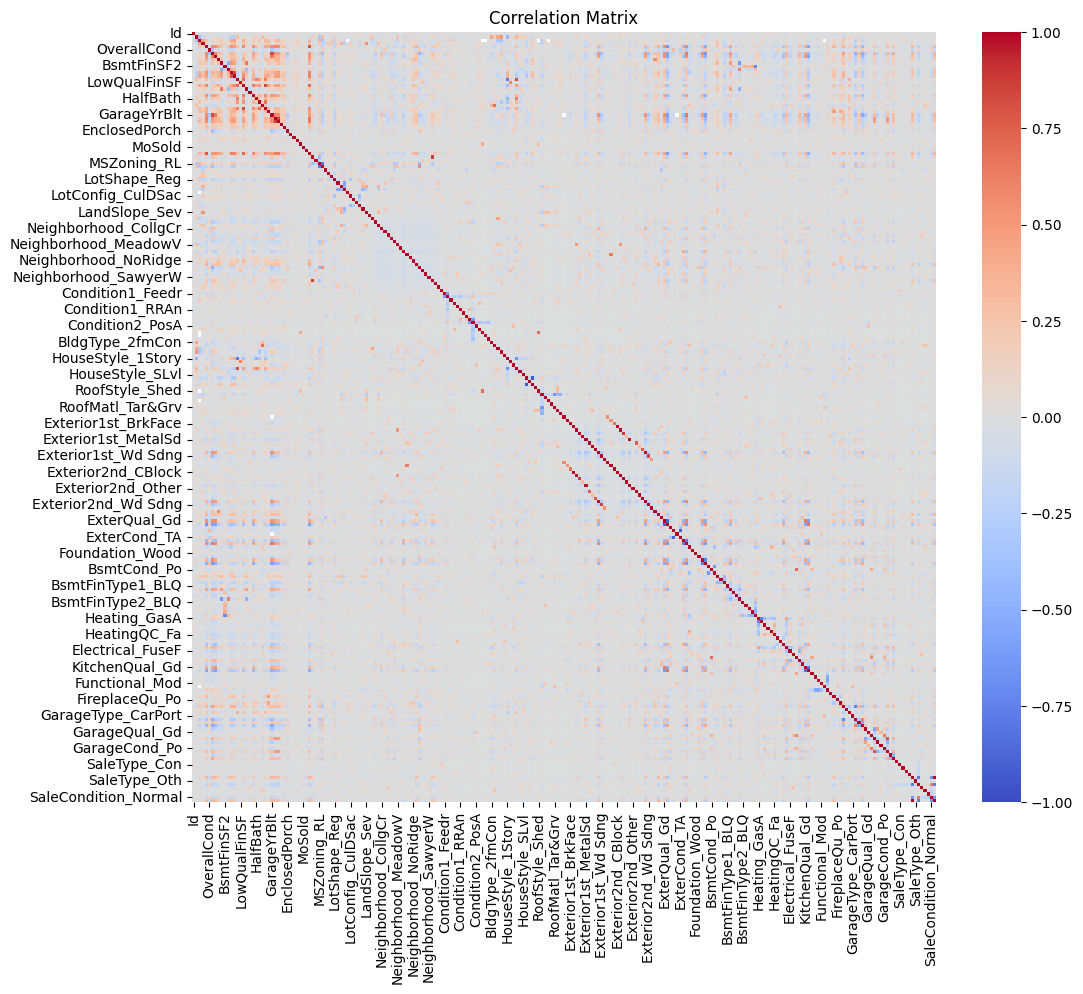

=== TOP 15 VARIABEL PALING BERPENGARUH (Positif) ===
SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
Foundation_PConc    0.497734
GarageYrBlt         0.486362
MasVnrArea          0.477493
Fireplaces          0.466929
ExterQual_Gd        0.452466
Name: SalePrice, dtype: float64

=== TOP 10 VARIABEL PENGARUH NEGATIF ===
BsmtExposure_No     -0.263600
LotShape_Reg        -0.267672
MSZoning_RM         -0.288065
HeatingQC_TA        -0.312677
Foundation_CBlock   -0.343263
GarageType_Detchd   -0.354141
GarageFinish_Unf    -0.410608
BsmtQual_TA         -0.452394
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, dtype: float64

=== VARIABEL PENGARUH LEMAH (bisa dibuang) ===
MasVnrType_BrkFace      0.198

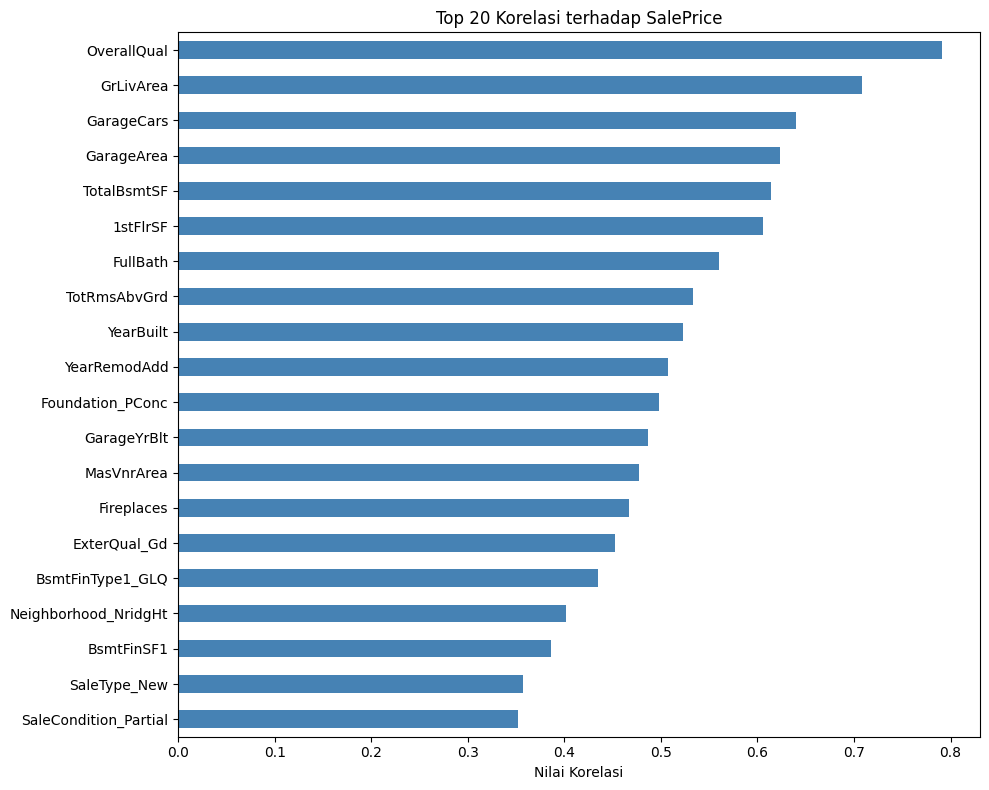


=== PASANGAN FITUR DENGAN KORELASI TINGGI (> 0.8) ===
1stFlrSF <-> TotalBsmtSF : 0.82
TotRmsAbvGrd <-> GrLivArea : 0.83
GarageYrBlt <-> YearBuilt : 0.83
GarageArea <-> GarageCars : 0.88
MSZoning_RM <-> MSZoning_RL : 0.81
Neighborhood_Somerst <-> MSZoning_FV : 0.86
HouseStyle_2Story <-> 2ndFlrSF : 0.81
RoofStyle_Hip <-> RoofStyle_Gable : 0.93
Exterior2nd_CBlock <-> Exterior1st_CBlock : 1.00
Exterior2nd_CmentBd <-> Exterior1st_CemntBd : 0.97
Exterior2nd_HdBoard <-> Exterior1st_HdBoard : 0.88
Exterior2nd_MetalSd <-> Exterior1st_MetalSd : 0.97
Exterior2nd_VinylSd <-> Exterior1st_VinylSd : 0.98
Exterior2nd_Wd Sdng <-> Exterior1st_Wd Sdng : 0.86
ExterQual_TA <-> ExterQual_Gd : 0.91
ExterCond_TA <-> ExterCond_Gd : 0.89
KitchenQual_TA <-> KitchenQual_Gd : 0.82
SaleCondition_Partial <-> SaleType_New : 0.99


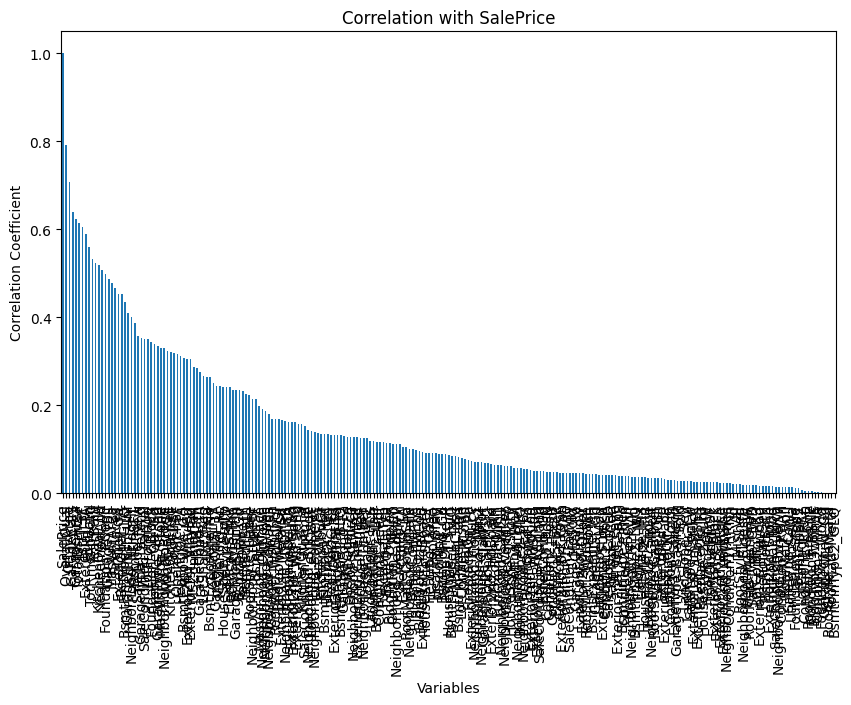

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Nei

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import numpy as np

test = pd.read_csv('/home/tenkai/Downloads/home-data-for-ml-course/test.csv')
train = pd.read_csv('/home/tenkai/Downloads/home-data-for-ml-course/train.csv')
missing_values = train.isnull().sum()

less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index
df = train.drop(columns=over)

df_Lencoded = pd.get_dummies(df, drop_first=True)


missing_values = df_Lencoded.isnull().sum()
missing_percetage = (missing_values / len(df_Lencoded)) * 100

missing_values = df_Lencoded.isnull().sum()
missing_percentage = (missing_values / len(df_Lencoded)) * 100
 
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)
 
missing_data[missing_data['Missing Values'] > 0] 

# Visualisasi distribusi data untuk beberapa kolom
# columns_to_plot = ['OverallQual', 'YearBuilt', 'LotArea', 'SaleType', 'SaleCondition']
     
# plt.figure(figsize=(15, 10))
# for i, column in enumerate(columns_to_plot, 1):
#     plt.subplot(2, 3, i)
#     sns.histplot(df[column], kde=True, bins=30)
#     plt.title(f'Distribution of {column}')
     
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(12, 10))
correlation_matrix = df_Lencoded.corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

corr_with_target = df_Lencoded.corr()['SalePrice'].sort_values(ascending=False)

print("=== TOP 15 VARIABEL PALING BERPENGARUH (Positif) ===")
print(corr_with_target.head(16))  # head(16) karena index 0 = SalePrice itu sendiri

print("\n=== TOP 10 VARIABEL PENGARUH NEGATIF ===")
print(corr_with_target.tail(10))

print("\n=== VARIABEL PENGARUH LEMAH (bisa dibuang) ===")
lemah = corr_with_target[(corr_with_target.abs() < 0.2) & (corr_with_target.index != 'SalePrice')]
print(lemah)

# 2. Visualisasi bar chart korelasi terhadap SalePrice
top_features = corr_with_target[1:21]  # ambil 20 teratas (skip SalePrice sendiri)
plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color=['red' if x < 0 else 'steelblue' for x in top_features.sort_values()])
plt.title('Top 20 Korelasi terhadap SalePrice')
plt.xlabel('Nilai Korelasi')
plt.tight_layout()
plt.show()

# 3. Cek multikolinearitas (fitur yang terlalu mirip satu sama lain)
print("\n=== PASANGAN FITUR DENGAN KORELASI TINGGI (> 0.8) ===")
corr_matrix = df_Lencoded.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns 
                   for row in upper.index 
                   if upper.loc[row, col] > 0.8]

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} <-> {pair[1]} : {pair[2]:.2f}")
else:
    print("Tidak ada pasangan fitur dengan korelasi > 0.8")


target_corr = df_Lencoded.corr()['SalePrice']
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with SalePrice')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

print(df_Lencoded.columns.tolist())